# Introduction 

The Glasgow Royal Infirmary (GRI) cohort is a retrospective colorectal cancer (CRC) cohort of stage I-III patients from Prof. Joanne Edward's lab. We are interesting in modelling the clinical data associated with these patients in order to predict cancer recurrence and survival probabilities of patients with CRC.

The competing risk is any other cause of death that is not CRC death or CRC recurrence. The event of interest is CRC death and CRC recurrence. 

This file contains a simple data preprocessing, where we look at missing values and filter columns and rows. 

# Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import missingno as msno
from sksurv.linear_model import CoxPHSurvivalAnalysis
import seaborn as sns


from helper import smart_fix_dtypes
from helper import clean_columns

pd.set_option("display.max_columns", None)
#pd.set_option("display.max_rows", None)



In [2]:
df = pd.read_excel("data/GRI_FullDataset.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

In [3]:
df

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM
0,1,TMA1,97,0.0,0.0,0,0.0,3.0,97.0,0.0,01.07.2020,01.07.2020,1.0,0.0,0.0,22.05.2012,01.03.1945,0.0,NaN,NaN,NaN,right and caecum,NaN,0.0,0.0,0.0,NaN,0.0,0.0,subtotal,11.05.2012,67.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,86.0,1.73,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Synch tumours,0.0,35.0,0.0,6.3,1.6,11.0,1.0,35.0,0.0,NaN,NaN,NaN,NaN,1.0,0.0,3.94,0.00,0.0,1.0,0.0,0.0,1.10,1600.0,NaN,13.0,4.0,2.0,0.81,0.0,0.69,1.0,1.6,0.0,1.0,7.02,0.0,1,1,1,49.49,31.21,37.93,0.0,103.0,1.0,1.0,5.63,1.0,2.17,1.0,5.07,0.0,2.0,0.21,0.0,1.0,0.35,0.0,0.0,65.00,0.0,25.81,1.0,14.27,1.0,0.86,0.0,2.82,0.0,118.25,1.26,0.0,119.51,2.07,121.45,1.0,29.33,1.0,141.0,1.0,23.0,0.0,137.0,1.0,23.0,1.0,NaN,285.0,NaN,1.0,122.0,1.0,179.0,1.0,127.0,0.0,167.0,0.0,111.0,0.0,136.0,0.0,175.0,0.0,240.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.62,1.0,82.42,0.0,101.62,1.0,135.82,3.67,0.0,NaN,NaN,NaN
1,2,TMA1,97,0.0,0.0,0,0.0,NaN,97.0,0.0,01.07.2020,01.07.2020,NaN,0.0,0.0,23.05.2012,27.12.1933,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,left,06.02.2012,78.0,2.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0

In [4]:
df[["CSS_months_2020", "DFS_months_2020", "DFS_status_July2020", "REC_n0_yes1", "UpdateJuly2020_a0_cd1_ncd2"]]

,CSS_months_2020,DFS_months_2020,DFS_status_July2020,REC_n0_yes1,UpdateJuly2020_a0_cd1_ncd2
0,97,97.0,0.0,0.0,0.0
1,97,97.0,0.0,0.0,0.0
2,50,25.0,1.0,1.0,1.0
3,83,83.0,2.0,0.0,2.0
4,96,96.0,0.0,0.0,0.0
...,...,...,...,...,...
781,103,103.0,2.0,0.0,2.0
782,53,29.0,1.0,1.0,1.0
783,145,145.0,2.0,0.0,2.0
784,52,52.0,2.0,0.0,2.0


### Missigness

In [5]:
print(df.isna().sum().to_string())

TMA_order                            0
TMA_number                           0
CSS_months_2020                      0
UpdateJuly2020_a0_cd1_ncd2           3
neoadj1                              2
Thirtyday_mortality_2017             0
c0r1                                 2
CMS_Raheleh_withoutlabels          352
DFS_months_2020                     23
DFS_status_July2020                 22
DateofLastFollowUp01072020           0
date_recurrence_01072020            23
MMR_Status_Jen                      26
adj1                                 2
el0em1                               2
dofsurg                              0
dob                                  0
REC_n0_yes1                         20
DFS_months                         569
DFS_years                          569
Vital_status_confirmed             722
Notes                              618
PrimaryCOD                         412
Recurrence_local1_distant2          25
Local_recurrenceKK                  25
Distant_recurrenceKK     

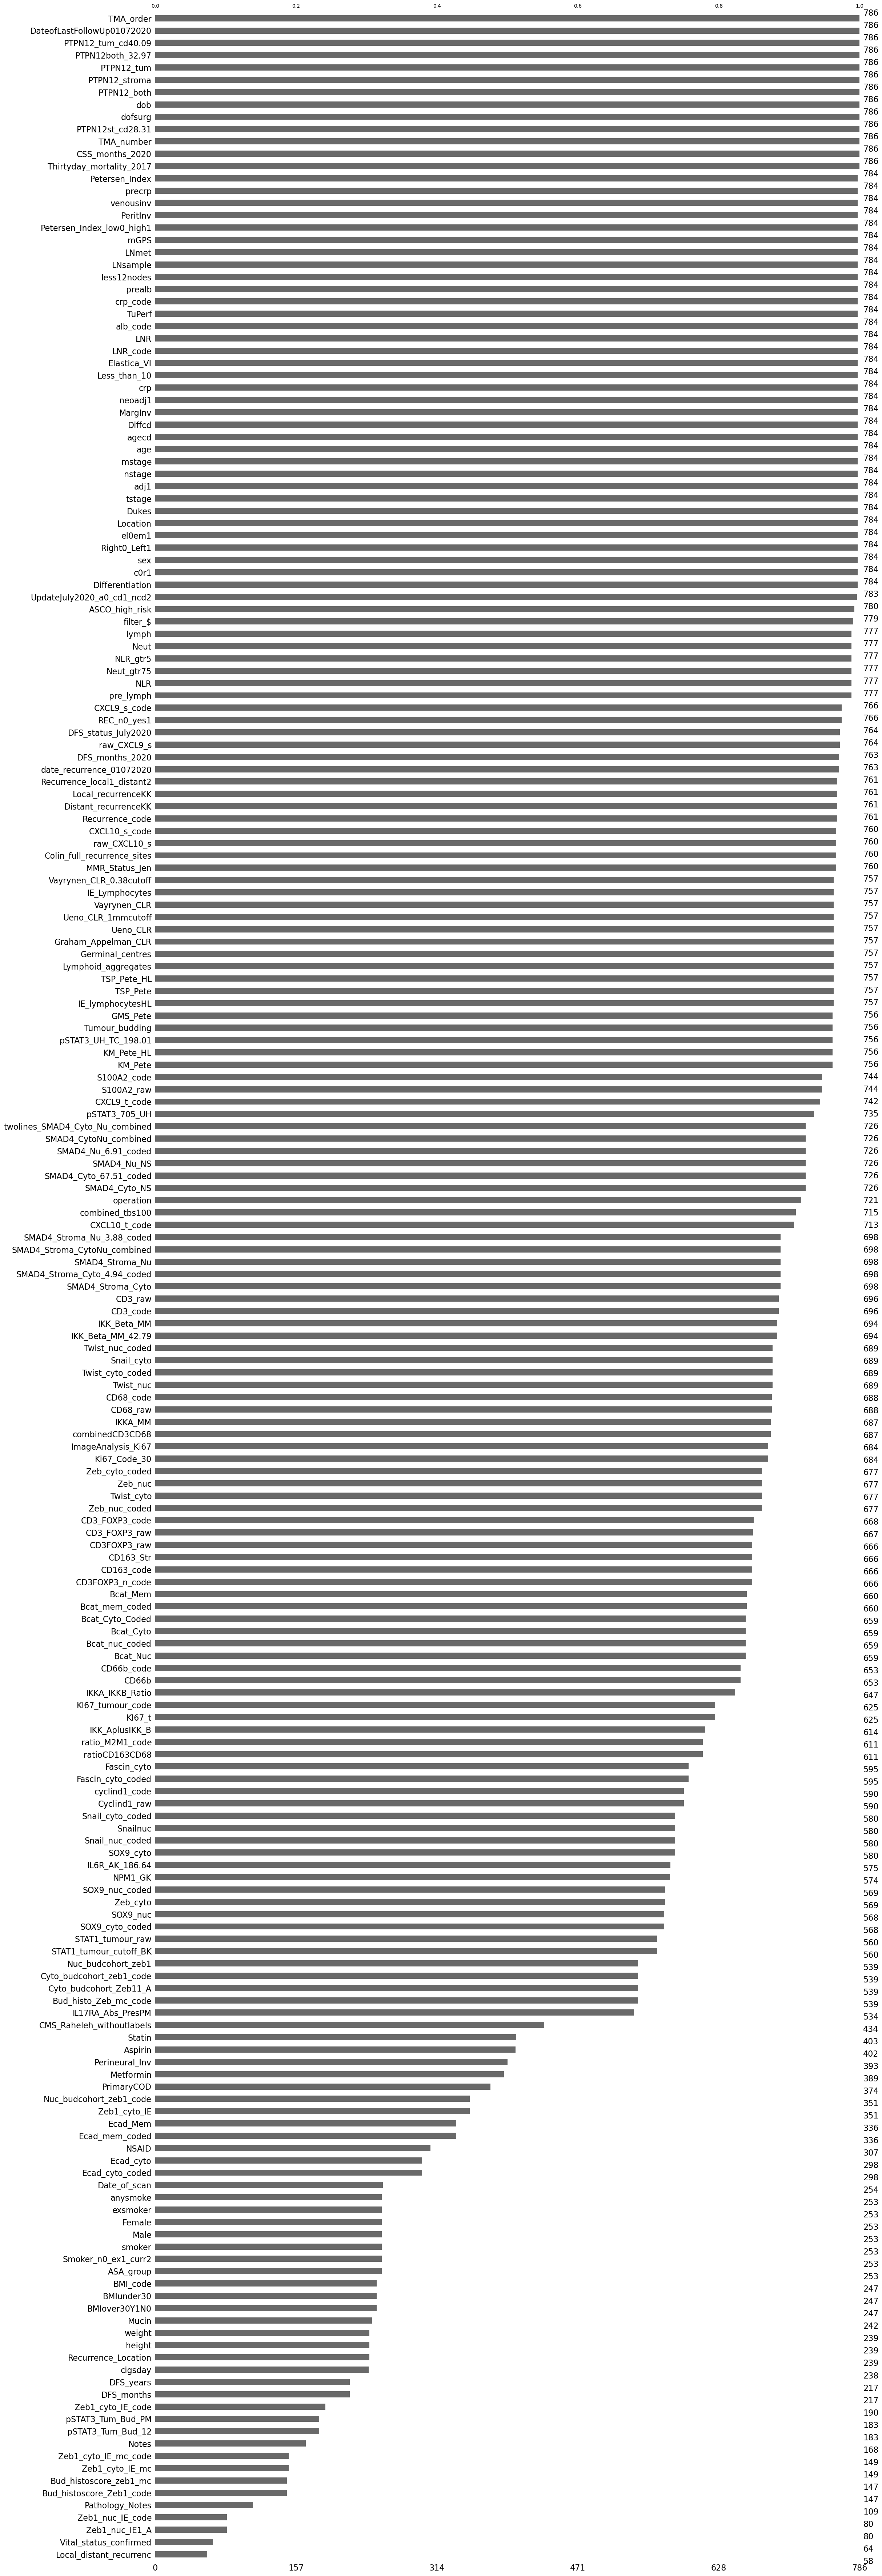

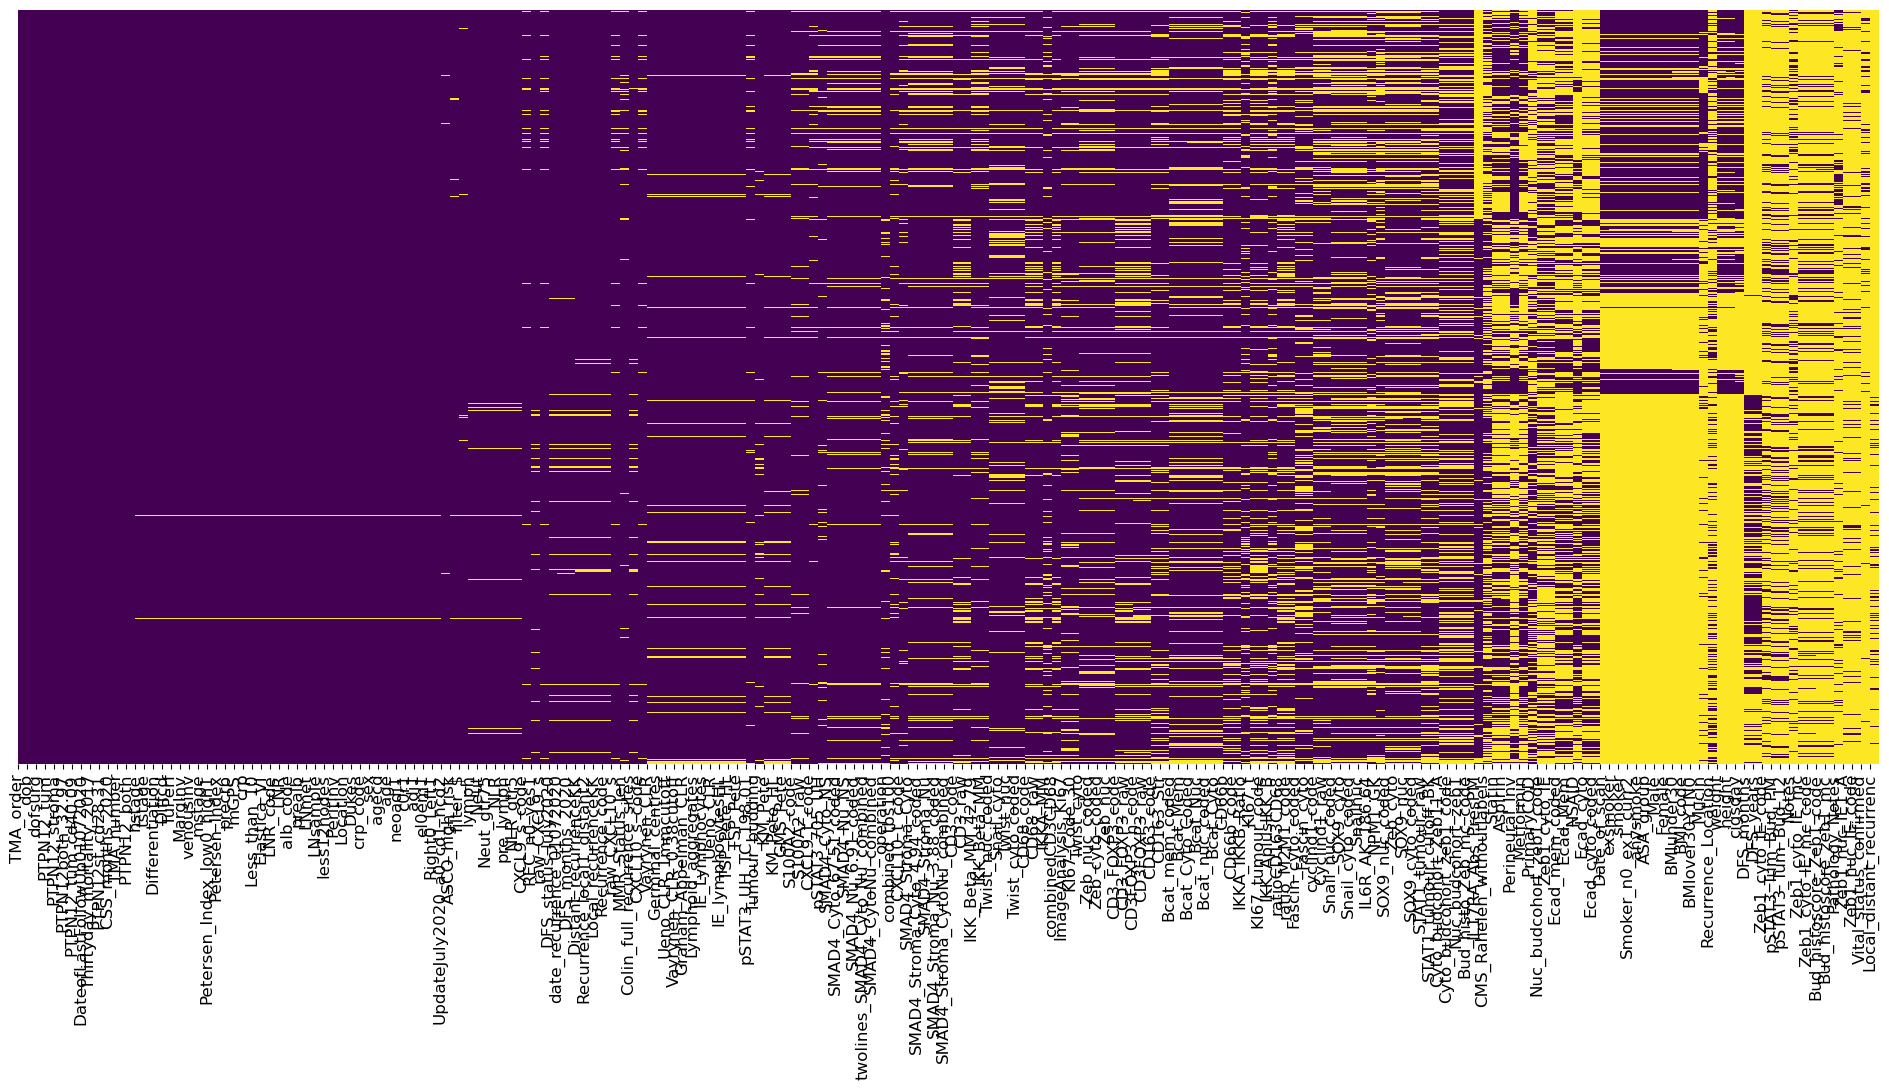

In [8]:
# Plot missigness
# Bar chart (missing counts per column)
msno.bar(df,  sort = "ascending")
plt.show()

# Heatmap of missing-value correlations
#msno.heatmap(df)
#plt.show()

plt.figure(figsize=(19, 11))

missing_order = df.isna().mean().sort_values()

df_sorted = df[missing_order.index]
ax = sns.heatmap(df_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df_sorted.columns)))
ax.set_xticklabels(df_sorted.columns, rotation=90, ha="center", fontsize=12)
ax.set_yticks([])
plt.tight_layout()

#### Preprocessing

Initial preprocessing includes exclusion criteria such not including those patients that have neoadjuvant therapy. 
Also, some patients gave the value 999 as NA, and the event is set as "12", instead of 0, 1 or 2.

Exclusion criteria: patients with neoadjuvant therapy

In [ ]:
df["neoadj1"].value_counts(dropna=False)

In [ ]:
df.shape

In [ ]:
# make a subset with those that contain neoadjuvant therapy 0
df = df[df["neoadj1"] == 0]

In [ ]:
df.shape

In [ ]:
df["UpdateJuly2020_a0_cd1_ncd2"].value_counts(dropna=False)

In [ ]:
df.loc[df['UpdateJuly2020_a0_cd1_ncd2'].isnull()]


In [ ]:
# we can keep the ones without nan in patient outcome
df = df[df["UpdateJuly2020_a0_cd1_ncd2"].notna()]

In [ ]:
df.loc[df['UpdateJuly2020_a0_cd1_ncd2'] == 12]

In [ ]:
# looking at the one with 12 as value 
df[df["UpdateJuly2020_a0_cd1_ncd2"] == 12]

# it is commented in Notes that the person moved. It is probably alive when that happened and so the most appropiate is a 0 (alive) as status. 
# Also REC_no0_yes1 suggests that there is no recurrence
df.loc[df["UpdateJuly2020_a0_cd1_ncd2"] == 12, "UpdateJuly2020_a0_cd1_ncd2"] = 0


In [ ]:
df.shape

In [ ]:
# Detecting some value of "999" what is inserted when NA
(df["neoadj1"] == 999).sum()

df["neoadj1"].value_counts(dropna=False)

print((df == 999).sum().to_string())

In [ ]:
# replace it with NA
df.replace(999, np.nan, inplace=True)

In [ ]:
## make the dates
data = df.copy()

# Convert dates from "dd.mm.yyyy" format
data["Date_of_scan"] = pd.to_datetime(df["Date_of_scan"], format="%d.%m.%Y", errors="coerce")
data["DateofLastFollowUp01072020"] = pd.to_datetime(df["DateofLastFollowUp01072020"], format="%d.%m.%Y", errors="coerce")
data["date_recurrence_01072020"] = pd.to_datetime(df["date_recurrence_01072020"], format="%d.%m.%Y", errors="coerce")
data["dofsurg"] = pd.to_datetime(df["dofsurg"], format="%d.%m.%Y", errors="coerce")
data["dob"] = pd.to_datetime(df["dob"], format="%d.%m.%Y", errors="coerce")

In [ ]:
# make the operation labels correctly
data["operation"] = data["operation"].astype(str).str.upper()

data["operation"] = data["operation"].str.replace(r"EXT RIGH", "EXT RT", regex=True)
data["operation"] = data["operation"].str.replace(r"EXT RH", "EXT RT", regex=True)

data["operation"] = data["operation"].str.replace(r"PROCTOCO", "PANPROCT", regex=True)
data["operation"] = data["operation"].str.replace(r"PROCTECT", "PANPROCT", regex=True)

data["operation"] = data["operation"].str.replace(r"(?<!\w)APR\s*\?(?!\w)", "APR", regex=True)

print(data["operation"].unique())


In [ ]:

df2 = data.copy()

# Condition for NA rows in any of these columns
na_mask = df2[["Recurrence_local1_distant2", "REC_n0_yes1", "Colin_full_recurrence_sites"]].isna().any(axis=1)

# Apply the same logic as in R
df2.loc[na_mask, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Recurrence_local1_distant2"]
)

df2.loc[na_mask, "Colin_full_recurrence_sites"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Colin_full_recurrence_sites"]
)

df2.loc[na_mask, "REC_n0_yes1"] = np.where(
    df2.loc[na_mask, "Recurrence_local1_distant2"] == 0,
    0,
    df2.loc[na_mask, "REC_n0_yes1"]
)

# Create a new label for Recurrence_local1_distant2, if the label is == to 4, means that it had recurrence and we do not know where. 
na_mask2 = df2["Recurrence_local1_distant2"].isna()

df2.loc[na_mask2, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask2, "REC_n0_yes1"] == 1,
    4,
    df2.loc[na_mask2, "Recurrence_local1_distant2"]
)



If there is any further info for DFS in other variable, we can take it from there to populate the one we will use. 

In [ ]:

df2.loc[df2["DFS_months_2020"].isna(), "DFS_months_2020"] = df2.loc[
    df2["DFS_months_2020"].isna(), "DFS_months"
]
filled = df2["DFS_months_2020"].notna() & data["DFS_months_2020"].isna()
filled_count = filled.sum()

In [ ]:
df2["DFS_months_test"] = ((df2["date_recurrence_01072020"] - df2["dofsurg"]).dt.days / 30.4375)
df2["CSS_months_test"] = ((df2["DateofLastFollowUp01072020"] - df2["dofsurg"]).dt.days / 30.4375)

Calculated DFS/CSS vs the given variables shows that they were rounding down, rather than up. 

In [ ]:
df2[["DFS_months_test", "DFS_months_2020", "CSS_months_2020", "CSS_months_test", "REC_n0_yes1", "UpdateJuly2020_a0_cd1_ncd2"]].head()

In [ ]:
np.min(df2["DFS_months_test"])

In [ ]:
np.min(df2["DFS_months_2020"])

Since some of the values can be negative, we modify it by 0. 

In [ ]:
df2.loc[df2["DFS_months_test"] < 0, "DFS_months_test"] = 0
df2.loc[df2["CSS_months_test"] < 0, "CSS_months_test"] = 0

Since death of CRC and recurrence will be our event of interest, CSS (cancer specific death) time can be used to populate missing values of DFS. We are interested mainly in time-to-recurrence (DFS), so we use this one and populate the missing values with CSS. 

In [ ]:
# amount of individuals with info in CSS but no DFS, because the time is for CRC death
filled = df2["DFS_months_2020"].isna() & df2["CSS_months_2020"].notna()
filled_count = filled.sum()
filled_count

Patients with NA in DFS but not in CSS (follow up time)

In [ ]:
df2.loc[df2["DFS_months_2020"].isna() & df2["CSS_months_2020"].notna(), 
            ["DFS_months_2020", "CSS_months_2020", "DFS_status_July2020", "UpdateJuly2020_a0_cd1_ncd2", "REC_n0_yes1"]
]

A total of 20 individuals do not have a DFS but do have CSS...

For the competing risk time, take the minimum between both the DFS and CSS. 

In [ ]:
df2["Cmprsk_time"] = df2[["DFS_months_test", "CSS_months_test"]].min(axis=1, skipna=True).round(0)
df2["Cmprsk_time"].isna().sum()

In [ ]:
df2["age_grp"] = np.where(df2["age"] < 40, "<40", "≥40")

plt.figure()
for g in ["<40", "≥40"]:
    x = df2.loc[df2["age_grp"] == g, "Cmprsk_time"].dropna()
    plt.hist(x, bins=30, density=True, alpha=0.5, label=g)
plt.xlabel("Cmprsk_time"); plt.ylabel("Density"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
df2 = df2.drop(columns="age_grp")

### Basic demographic 

In [ ]:
print(df2.columns.to_list())

In [ ]:
df2["sex"].value_counts(normalize=True) * 100

In [ ]:
df2["age"].mean()

In [ ]:
# primary cancer location
df2["Location"].value_counts(dropna=False) / (len(df2["Location"])) * 100

In [ ]:
# percentage of early on-set
sum(df2["age"] <= 50) / (len(df2["age"])) * 100

In [ ]:
df2["el0em1"].value_counts(dropna=False) / (len(df2["el0em1"])) * 100

In [ ]:
df2["Thirtyday_mortality_2017"].value_counts(dropna=False) / (len(df2["Thirtyday_mortality_2017"])) * 100

In [ ]:
df2["tstage"].value_counts(dropna=False) / (len(df2["tstage"])) * 100

In [ ]:
df2["mstage"].value_counts(dropna=False)

Calculation of LN ratio 

In [ ]:
## super important to calculate the ratio of limph nodes that are positive
df2["LNratio"] = np.where( df2["LNsample"] == 0, 0, (df2["LNmet"] / df2["LNsample"]).round(3))

# it might be actually not needed since it is already calculated as LNR

In [ ]:
df2["Cmprsk_time"].mean()

### Variables for competing risks

Basically it is the same as the event indicator, but if they had recurrence, they are treated like if they died by other causes.
It requires the last follow up information recorded in "UpdateJuly2020_a0_cd1_ncd2", and the Disease free status information from "DFS_status_July2020".
If it has had recurrence meaning DFS_status_July == 1, then that is our event of interest now.

Recurrence/died of cancer = event of interest

Alive without recurrence = censor

Died of other causes without recurrece = competing event



In [ ]:
df2["UpdateJuly2020_a0_cd1_ncd2"].isna().sum()

In [ ]:
df2["DFS_status_July2020"].isna().sum()

There is Nan in both DFS and patient outcome, but not shared. Therefore we can repopulate one with the other. 

In [ ]:
df2[df2["DFS_status_July2020"].isna() &  df2["UpdateJuly2020_a0_cd1_ncd2"].isna()]

How has the DFS been calculated? can we replicate it?

In [ ]:
dfs_status = np.select(
    [
        (df["REC_n0_yes1"] == 1), # recurrence
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 1), # cancer-specific death
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 0) & (df["REC_n0_yes1"] == 0),  # alive, no recurrence
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 2) & (df["REC_n0_yes1"] == 0),  # other-cause death, no recurrence
    ],
    [1, 1, 0, 2],
    default=np.nan
)

df2["DFS_status_test"] = dfs_status


In [ ]:
df2[["UpdateJuly2020_a0_cd1_ncd2","REC_n0_yes1","DFS_status_test","DFS_status_July2020"]]

The testing variable and the real one differ in few rows, mainly because of missing values. Those missing values are complete in the main patient outome definition `UpdateJuly2020_a0_cd1_ncd2`

In [ ]:
df2.loc[df2["DFS_status_test"] != df2["DFS_status_July2020"], ["UpdateJuly2020_a0_cd1_ncd2", "DFS_status_test", "DFS_status_July2020", "DFS_months_2020", "CSS_months_2020", "REC_n0_yes1"]]


We can then easily use to compute the competing risk status variable the `UpdateJuly2020_a0_cd1_ncd2` and adjust with DFS. 

In [ ]:
df2["Cmprsk_Status"] = df2["UpdateJuly2020_a0_cd1_ncd2"]
df2["Cmprsk_Status"] = np.where(df2["DFS_status_July2020"] == 1, 1,  df2["Cmprsk_Status"])

In [ ]:
mask = df2["Cmprsk_Status"].isna()

df2[mask]

Drop if there is no outcome recorded, and therefore no cmprsk status


In [ ]:
time, status = "Cmprsk_time", "Cmprsk_Status"

print(df2[[time, status]].isna().sum())

# drop if we do not know any of these two:
df2 = df2.dropna(subset=[time, status])


In [ ]:
df2["Cmprsk_Status"].value_counts(normalize=True) * 100

In [ ]:
df2["UpdateJuly2020_a0_cd1_ncd2"].value_counts(normalize=True) * 100

In [ ]:
df2["REC_n0_yes1"].value_counts(normalize=True) * 100

In [ ]:
df2["REC_n0_yes1"].value_counts(dropna=False)

In [ ]:
df2.loc[df2["REC_n0_yes1"].isna(), ]

In [ ]:
df2.loc[df2["REC_n0_yes1"] == 0, "DFS_months_2020"].mean()

In [ ]:
df2.loc[df2["REC_n0_yes1"] == 1, "DFS_months_2020"].mean()

It is not easy to define the event of interest, since we have cases where they might have died of other causes but they have had recurrence as well. 
Since we are primarily interested in recurrence, we have to prioritize it. Therefore, if it has had recurrence, we would assign it the event of interest regardless of the other cause of death.

Some examples where the overall status, does not correspond with the disease free status:


In [ ]:
mask = df2["UpdateJuly2020_a0_cd1_ncd2"] != df2["DFS_status_July2020"]
df2.loc[mask, ["UpdateJuly2020_a0_cd1_ncd2", "DFS_status_July2020", "REC_n0_yes1", "Cmprsk_Status"]]

In [ ]:
df2


# Quality Performance Indicators (QPIs)
## Colorectal cancer quality performance indicator (QPI) documentation

https://publichealthscotland.scot/population-health/conditions-and-diseases/cancer/cancer-quality-performance-indicators-qpis/quality-performance-indicators-qpis/qpi-documentation/


https://publichealthscotland.scot/publications/colorectal-cancer-quality-performance-indicator-qpi-documentation/colorectal-cancer-quality-performance-indicator-qpi-documentation-1-april-2021-onwards/

01 May 2023 (Latest release)

National cancer quality performance indicators have been developed to support continuous quality improvement in cancer care (CEL 06 2012). NHS Boards are required to report these indicators against a clinically agreed indicator specific target as part of the mandatory national cancer quality programme. They have been developed collaboratively by North Cancer Alliance, South East Scotland Cancer Network, West of Scotland Cancer Network, Healthcare Improvement Scotland and PHS.

They are recorded to evaluate if patients with colorectal cancer are receiving a high standard of care. 

| **Field Name** | **Description**                                             | **Required for QPI(s)**              |
| -------------- | ----------------------------------------------------------- | ------------------------------------ |
| DATEIMAGELB    | Date of Imaging Large Bowel                                 | QPI 2                                |
| DIAGDATE       | Date of Diagnosis (Cancer)                                  | QPI 1, 2, 5, 7, 8, 9, 10, 11, 12, 16 |
| SITEPRIM       | Site of Origin of Primary Tumour (Cancer)                   | QPI 1, 7                             |
| FINSURGDATE    | Date of Final Definitive (or Only) Surgery                  | QPI 2, 7, 10, 11                     |
| PRESENT        | Presentation Type (Elective/Emergency)                      | QPI 1, 2, 7, 10                      |
| OPINTENT       | Intent of Surgery (Curative/Palliative)                     | QPI 1, 2, 5                          |
| REOPER         | Re-operation after definitive surgery                       | QPI 8                                |
| ANASLEAK       | Anastomotic Leak after surgery                              | QPI 9                                |
| CIRCMARGIN     | Circumferential Margin Involved (surgical specimen)         | QPI 7                                |
| LNEXAMINE      | Final Total Number of Lymph Nodes Examined                  | QPI 5                                |
| FINALN         | TNM Nodal Classification (Final)                            | QPI 11                               |
| FINALT         | TNM Tumour Classification (Final)                           | QPI 11                               |
| FINALM         | TNM Metastasis Classification (Final)                       | QPI 11                               |
| NEOONC         | Neo-Adjuvant Oncology Treatment Type                        | QPI 11                               |
| ADJONC         | Primary/Palliative/Adjuvant Oncology Treatment Type         | QPI 1                                |
| ADJONC\_DATE   | Date Primary/Palliative/Adjuvant Oncology Treatment Started | QPI 11                               |
| LIVERDIAGDATE  | Date of Liver Imaging confirming liver mets                 | QPI 15                               |
| HPBMDT         | Referral to HPB MDT (liver mets patients)                   | QPI 15                               |
| BRAF           | BRAF mutation status                                        | QPI 16                               |
| MSISTATUS      | Microsatellite Instability (MSI) Status                     | QPI 16                               |
| IHCSTATUS      | Mismatch Repair (MMR IHC)                                   | QPI 16                               |
| GENETICS       | Genetics Referral                                           | QPI 16                               |
| TRIAL          | Patient entered into Clinical Trial                         | Generic QPIs                         |

The QPI's names are the following:

| **QPI** | **Name**                                                      |
| ------- | ------------------------------------------------------------- |
| QPI 1   | Radiological Diagnosis of Colorectal Cancer                   |
| QPI 2   | Pre-operative Imaging of Colon                                |
| QPI 3   | *Retired* (Staging Laparoscopy – removed in earlier versions) |
| QPI 4   | Pre-operative MRI in Rectal Cancer                            |
| QPI 5   | Lymph Node Yield                                              |
| QPI 6   | Pre-operative Radiotherapy in Rectal Cancer                   |
| QPI 7   | Clear Surgical Margins                                        |
| QPI 8   | Re-operation                                                  |
| QPI 9   | Anastomotic Leak                                              |
| QPI 10  | Emergency Surgery                                             |
| QPI 11  | Pathological Staging                                          |
| QPI 12  | Adjuvant Chemotherapy in Stage III Colon Cancer               |
| QPI 13  | Adjuvant Radiotherapy in Rectal Cancer                        |
| QPI 14  | Adjuvant Chemotherapy in Rectal Cancer                        |
| QPI 15  | Imaging for Liver Metastases                                  |
| QPI 16  | Molecular Pathological Markers                                |

In our dataset we have lots of more variables, some of them can be understood as extenstion of the standard QPI's. For instance the GRI contains more genertic and pathology variables, which in the future could be converted into the standard practise.


In our dataset:

| **GRI column**            | **QPI dataset variable**                    | **QPI No.**                         | **QPI Name**                                                                     |
| ---------------------------------- | ------------------------------------------- | ----------------------------------- | -------------------------------------------------------------------------------- |
| `UpdateJuly2020_a0_cd1_ncd2`       | Treatment update / recurrence status fields | QPI 12                              | Adjuvant Chemotherapy in Stage III Colon Cancer                                  |
| `Thirtyday_mortality_2017`         | 30-day mortality (audit item, not a QPI)    | –                                   | –                                                                                |
| `MMR_Status_Jen`                   | `MSISTATUS` / `IHCSTATUS`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `BRAF`                   | `BRAF`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `dofsurg` (date of surgery)        | `FINSURGDATE`                               | QPI 2, 7, 10, 11                    | Definitive Surgery / Surgical Margins / Emergency Surgery / Pathological Staging |
| `operation`                        | `OPINTENT`                                  | QPI 1, 2, 5                         | Surgical Intent (Curative/Palliative)                                            |
| `sex` / `Female` / `Male`          | `SEX`                                       | Background (not QPI)                | –                                                                                |
| `Location` / `Right0_Left1`        | `SITEPRIM`                                  | QPI 1, 7                            | Radiological Diagnosis / Clear Surgical Margins                                  |
| `tstage` / `nstage` / `mstage`     | `FINALT` / `FINALN` / `FINALM`              | QPI 11                              | Pathological Staging                                                             |
| `Differentiation`                  | `DIFFERENT` (if present)                      | Not core QPI (but pathology detail) | –                                                                                |
| `LNratio` | `LNEXAMINE`                                 | QPI 5                               | Lymph Node Yield                                                                 |
| `MargInv`                          | `CIRCMARGIN`                                | QPI 7                               | Clear Surgical Margins                                                           |
| `Recurrence_local1_distant2`       | Recurrence coding                           | QPI 12–14                           | Adjuvant therapy follow-up                                                       |
| `PrimaryCOD`                       | Cause of death                              | Background (not QPI)                | –                                           |


Additionally we have the BRAF mutation status.

Lots of recurrence and competing risk status do not appear in the QPI's but they are quite useful


Regarding the genetics or QPI 16, we miss MLH1 in GRI. Overall QPI miss lots of important variables like tumor budding etc. 


Let's add the mutation data

In [ ]:
mutations = pd.read_excel("data/Mutations_GRI.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

mutations

In [ ]:
df3 = df2.merge(mutations, on="TMA_order") 

In [ ]:
df3.to_csv("data/GRI_preprocess-1.csv")

In [ ]:
df3

Which of te QPIs can be predictive?

In [ ]:
qpis = [
    #"UpdateJuly2020_a0_cd1_ncd2",
    #"Thirtyday_mortality_2017", # not for prediction and part od DFS_months
    "MMR_Status_Jen",
    "BRAF",
    #"dofsurg", #not for prediction
    #"operation", # operation has causal blind spots
    "sex",
    "Location", "Right0_Left1",
    "tstage", "nstage", "mstage",
    "Differentiation",
    "LNratio",
    "MargInv",
    #"Recurrence_local1_distant2", #not for prediction
    #"PrimaryCOD", # removing this since we gave cmprsk status
    "DFS_months_2020",
    #"DFS_status_July2020", # moved to Cmprsk_Status
    "Cmprsk_Status"
]

df_qpis = df3[qpis]

In [ ]:
df_qpis

In [ ]:
print(df_qpis.isna().sum().to_string())


In [ ]:
#sns.heatmap(df_qpis.isna(), cbar=False, cmap="viridis")

df_qpis_short = df_qpis.dropna(axis = 0)

print(df_qpis.shape)   


Just as an example... this would require proper missing data inputation.

### Remove columns that we do not need

These are columns highly missing (smoke, weight...), like >50%





In [ ]:
df3["ASA_group"].isna().sum()

In [ ]:
df3[["LNratio", "LNR"]]

df3["LNratio"].equals(df3["LNR"])

#print(df3[["LNratio", "LNR"]])

diff_mask = df3["LNratio"] != df3["LNR"]
df3.loc[diff_mask, ["LNratio", "LNR"]]

# we shall then keep the LNratio

In [ ]:
print(df3.columns.to_list())

In [ ]:
df3.shape

We can drop some covariates that are coded version of continues variables. There is one coded version per each continous biomarker. 

We can also drop treatment variables, since including them as predictors would cause causal blind spots, immortal time bias, etc. 

Variables used to calculate DFS or competing risks status are also not longer needed. 

Some varibles such weight, height and BMI are highly missing and then we can remove them. 


In [ ]:
df4 = df3.drop(labels=['TMA_number',"CSS_months_2020", "UpdateJuly2020_a0_cd1_ncd2", "neoadj1", "Thirtyday_mortality_2017",
                 "CMS_Raheleh_withoutlabels", "DFS_status_July2020", 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 
                 'dofsurg', 'dob', 'DFS_months', 'DFS_years', "Vital_status_confirmed", "Pathology_Notes", 'Notes', 'PrimaryCOD', 'Local_recurrenceKK', 
                 'Distant_recurrenceKK', 'Recurrence_Location', 'Recurrence_code', 'operation', 'Date_of_scan', 
                 'agecd','Female', 'Male','Diffcd', 'Petersen_Index_low0_high1', 'TSP_Pete_HL', 'KM_Pete_HL', 'weight', 'height', 'BMI_code', 'BMIunder30', 
                 'BMIover30Y1N0', 'Smoker_n0_ex1_curr2', 'smoker', 'cigsday', 'exsmoker', 'anysmoke','LNmet', 'LNsample', 'less12nodes',
                 'crp_code', 'alb_code', 'Aspirin', 'NSAID', 'Statin', 'Metformin', 'Mucin', 'NLR_gtr5', 'Neut_gtr75','LNR_code', 'Less_than_10', 
                 'ASCO_high_risk', 'Ueno_CLR_1mmcutoff', 'Vayrynen_CLR_0.38cutoff', 'IE_lymphocytesHL', 'filter_$', 'Ki67_Code_30', 'PTPN12st_cd28.31',	
                 'PTPN12_tum_cd40.09',	'PTPN12both_32.97',
                 # testing variables
                 'DFS_status_test','DFS_months_test', 'CSS_months_test', 'DFS_months_2020',
                 # remove all same value
                 'mstage',
                 # remove dukes
                 "Dukes",
                 # remove duplicates
                 'LNR', "ImageAnalysis_Ki67", 
                 # remove duplicate that was recommended by Jo
                 "venousinv", "CD3FOXP3_raw", # maybe the other one
                 # remove ratios
                 'ratioCD163CD68', 'ratio_M2M1_code', 'IKKA_IKKB_Ratio', 'NLR',
                 # remove redundant
                 "Right0_Left1", "c0r1",
                 # remove composites
                 "Petersen_Index", "KM_Pete", "GMS_Pete", "mGPS", "IKK_AplusIKK_B",
                 # remove unclear definitions
                 "Graham_Appelman_CLR", "Ueno_CLR", "Vayrynen_CLR",
                 # remove treatment options
                 "adj1",
                 # coded versions of raw and combinations:
                 'S100A2_code', 'combined_tbs100', 'CD3_code', 'CD3_FOXP3_code', 'CD68_code', 'combinedCD3CD68', 'CXCL9_s_code', 'CXCL9_t_code',
                 'CXCL10_s_code', 'CXCL10_t_code', 'cyclind1_code', 'KI67_tumour_code', 'CD163_code', 'CD66b_code',
                 'STAT1_tumour_cutoff_BK',  'CD3FOXP3_n_code', 'Bcat_Cyto_Coded', 'Bcat_nuc_coded', 'Bcat_mem_coded', 'Fascin_cyto_coded', 
                 'Ecad_cyto_coded', 'Ecad_mem_coded', 'Zeb_cyto_coded','Zeb_nuc_coded', 'Twist_cyto_coded', 'IKK_Beta_MM_42.79',
                 'Twist_nuc_coded', 'Snail_cyto_coded', 'Snail_nuc_coded', 'SOX9_cyto_coded', 'SOX9_nuc_coded',
                 'SMAD4_Cyto_67.51_coded', 'SMAD4_Nu_6.91_coded', 'SMAD4_CytoNu_combined', 'twolines_SMAD4_Cyto_Nu_combined', 
                 'SMAD4_Stroma_Cyto_4.94_coded', 'SMAD4_Stroma_Nu_3.88_coded', 'SMAD4_Stroma_CytoNu_combined', 'Zeb1_cyto_IE_code', 
                 'Zeb1_cyto_IE_mc_code', 'Bud_histoscore_Zeb1_code', 'Bud_histo_Zeb_mc_code', 'Cyto_budcohort_zeb1_code', 
                 'Nuc_budcohort_zeb1_code', 'pSTAT3_UH_TC_198.01', 'pSTAT3_Tum_Bud_12', 'PTPN12_both' ], axis=1)

                

For IL6 we only have a coded version so we leave it. 

Maybe some ratios should be removed too. 

In [ ]:
df4

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(df4.isna(), cbar=False, cmap="viridis")

plt.xticks(rotation=90, fontsize=8)  
plt.yticks([])         
plt.show()

Also removing those columns where we have more than 50% of missing values, since we will perform MICE. 

In [ ]:

df4.shape


In [ ]:
k = int(np.ceil(0.5 * df4.shape[0]))  # required non-NA per row
k

In [ ]:
df5 = df4.dropna(axis=1, thresh=k)
df5

In [ ]:

#dropped columns
df4.columns.difference(df5.columns)


In [ ]:
plt.figure(figsize=(17.5, 13))

missing_order = df5.isna().mean().sort_values()

df5_sorted = df5[missing_order.index]
ax = sns.heatmap(df5_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df5_sorted.columns)))
ax.set_xticklabels(df5_sorted.columns, rotation=90, ha="center", fontsize=12)
ax.set_yticks([])
plt.tight_layout()

In [ ]:
df5.shape

In [ ]:
msno.bar(df5,  sort = "ascending")
plt.show()

However the columns might not be with the correct type

In [ ]:
df5.dtypes
df5.info()

In [ ]:
df6 = smart_fix_dtypes(df5, cat_threshold=10)
#print(df5.dtypes)
df6.info()

Some further organization of values in certain columns:

In [ ]:
df6["Differentiation"].value_counts(dropna=False)

Map considering the recommendations in the QPIs:

In [ ]:
_map = { 
    # Well/Moderate
    "well": "Well/Moderate", "welll": "Well/Moderate",
    "mod": "Well/Moderate", "moderate": "Well/Moderate",
    "mod/well": "Well/Moderate", "well/mod": "Well/Moderate",

    # Poor / undiff
    "poor": "Poor/Undiff", "mod/poor": "Poor/Undiff", "poor/mod": "Poor/Undiff", "undiff": "Poor/Undiff",
    "mucin": "Poor/Undiff", "mucinous": "Poor/Undiff", "muscious": "Poor/Undiff",
    # Mucinous olnly two labels
    #"mucin": "Mucinous", "mucinous": "Mucinous", "muscious": "Mucinous",
}

# normalize to lowercase first, then map
s = df6["Differentiation"].astype(str).str.strip().str.lower()
df6["Differentiation"] = s.map(_map)

# quick check
print(df6["Differentiation"].value_counts(dropna=False))

In [ ]:
df6["TSP_Pete"].value_counts(dropna=False)

In [ ]:
df6["tstage"].value_counts(dropna=False) / len(df6["tstage"]) * 100


We are going to group the stage of I and II, we saw in preliminary analysis that the hazard ratios had really high confidence intervals.

In [ ]:
t = pd.to_numeric(df6["tstage"], errors="coerce")
df6["tstage"] = t.map({1: "I–II", 2: "I–II", 3: "III", 4: "IV"})

In [ ]:
df6["tstage"].value_counts(dropna=False)

In [ ]:
df6["MMR_Status_Jen"].value_counts(dropna=False)

In [ ]:
df6["TuPerf"].value_counts(dropna=False) / len(df6["TuPerf"]) * 100

In [ ]:
df6.columns

In [ ]:
df6.shape

In [ ]:
msno.bar(df6)
plt.show()

### Correlation plots

Numeric variables

In [ ]:
num = df6.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 16))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  va="center", fontsize=8)
ax.set_title("Correlation matrix", pad=20)
plt.show()

In [ ]:
corr = num.corr(method="spearman")

# Keep only upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Extract correlated pairs > 0.8
high_corr = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
        .query("corr > 0.8")
        .sort_values("corr", ascending=False)
)

print(high_corr)


In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_upper = corr.where(mask)

# Pairs with corr > 0.8
pairs = (
    corr_upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
    .query("corr > 0.8")
    .sort_values("corr", ascending=True)
)
print(pairs)

# Bar plot of correlated pairs
plt.figure(figsize=(6, max(2, 0.35*len(pairs))))
plt.barh(pairs.apply(lambda r: f"{r.var1} — {r.var2}", axis=1), pairs["corr"])
plt.xlabel("Spearman correlation")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["Bcat_Nuc"], df6["Bcat_Mem"])

We can see that some variables are highly correlated. 

For instance preoperative crp and crp, as well as preoperative lymphocites and lymphocites. 

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["precrp"], df6["crp"])

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["pre_lymph"], df6["lymph"])

Joanne Edwards lab suggested that preoperative measure are preferable. We can delete the non-preoperative ones.

In [ ]:
df7 = df6.drop(labels=["crp", "lymph"], axis=1)

df7

In [ ]:
df8 = df7.drop(
    columns=[
        "SMAD4_Cyto_NS",
        "SMAD4_Stroma_Cyto",
        "PTPN12_stroma",
        "SMAD4_Stroma_Nu",
        "Cyto_budcohort_Zeb11_A",
        "Bcat_Cyto",
        "Bcat_Mem"
    ],
    errors="ignore")


In [ ]:
df8.columns

In [ ]:
num = df8.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 16))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  va="center", fontsize=8)
ax.set_title("Correlation matrix", pad=20)
plt.show()

In [ ]:
num = df8.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

# Keep only upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Extract correlated pairs > 0.8
high_corr = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
        .query("corr > 0.8")
        .sort_values("corr", ascending=False)
)

print(high_corr)

In [ ]:
df8.shape

### Class imbalance of categories

In [ ]:

import matplotlib.ticker as mticker


cat = df8.select_dtypes(include=["object", "category", "bool", "int8"]).copy()
n = len(cat.columns)
fig, axes = plt.subplots(nrows=len(cat.columns), ncols=1, figsize=(8, 2.6 * n), constrained_layout=True)

for ax, col in zip(axes, cat.columns):
    vc = cat[col].value_counts(normalize=True, dropna=False)
    order = vc.sort_values(ascending=False).index
    vals = vc.loc[order].values
    labels = [("NA" if pd.isna(x) else str(x)) for x in order]

    sns.barplot(
        x=vals,
        y=labels,
        hue=labels,              # suppresses deprecation warning
        palette="viridis",
        dodge=False,
        legend=False,
        orient="h",
        ax=ax
    )

    ax.set_xlabel("Percentage")
    ax.set_ylabel("")
    ax.set_title(col)
    xmax = max(0.1, vals.max())
    ax.set_xlim(0, xmax * 1.12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.margins(y=0.05)

    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, f"{v*100:.1f}%", va="center", ha="left", fontsize=9, clip_on=False)

plt.show()

Further analysis to be done with Elastica_VI and Venous Invasion, it is referring to the same. 

We can drop covariate if less that 5% counts in a column.

In [ ]:
df8 = df8.drop(columns=["TuPerf"])

In [ ]:
df8.shape

### Metadata

We can create some metadata

Sources:

https://pmc.ncbi.nlm.nih.gov/articles/PMC8580263/

https://www.nature.com/articles/s41598-023-28631-y


QPIS data


In [ ]:
COL_META = {
    "TMA_order": {"name": "TMA_Order", "origin": "Clinical", "qpis": "no", "collection": "research"},
    "DFS_months_2020": {"name": "Disease_Free_Survival_Months", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "adj1": {"name": "Adjuvant_Therapy", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "el0em1": {"name": "Emergency_Surgery", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Recurrence_local1_distant2": {"name": "Recurrence_Code_Local1_Distant2", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Colin_full_recurrence_sites": {"name": "Recurrence_Sites", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "REC_n0_yes1": {"name": "Recurrence_Indicator", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "age": {"name": "Age", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "sex": {"name": "Sex", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Location": {"name": "Tumour_Location", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Dukes": {"name": "Dukes_Stage", "origin": "Staging", "qpis": "no", "collection": "routine"},
    "tstage": {"name": "T_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "nstage": {"name": "N_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "mstage": {"name": "M_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    # derived for this analysis
    "Cmprsk_Status": {"name": "Outcome", "origin": "Clinical", "qpis": "yes", "collection": "research"},
    "Cmprsk_time": {"name": "Time", "origin": "Clinical", "qpis": "yes", "collection": "routine"},

    # blood - Laboratory
    "Neut": {"name": "Neutrophils", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "lymph": {"name": "Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "precrp": {"name": "Preoperative_CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "prealb": {"name": "Preoperative_Albumin", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "crp": {"name": "CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "pre_lymph": {"name": "Preoperative_Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},

    # pathology 
    "Lymphoid_aggregates": {"name": "Lymphoid_Aggregates", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Germinal_centres": {"name": "Germinal_Centres", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "IE_Lymphocytes": {"name": "Intraepithelial_Lymphocytes", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "ImageAnalysis_Ki67": {"name": "Ki67_Image_Analysis", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Differentiation": {"name": "Histological_Grade", "origin": "Pathology", "qpis": "yes", "collection": "routine"},
    "Tumour_budding": {"name": "Tumour_Budding", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TuPerf": {"name": "Tumour_Perforation", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "MargInv": {"name": "Margin_Invasion", "origin": "Pathology", "qpis": "yes", "collection": "routine"}, # if qpis then routine
    "venousinv": {"name": "Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "PeritInv": {"name": "Peritoneal_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TSP_Pete": {"name": "Tumour_Stroma_Percentage", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "LNratio": {"name": "Lymph_Node_Ratio", "origin": "Pathology", "qpis": "yes", "collection": "research"},
    "Elastica_VI": {"name": "Elastica_Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "MMR_Status_Jen": {"name": "MMR_Status", "origin": "Pathology", "qpis": "yes", "collection": "routine"},

    # multiplex
    "CD3_raw": {"name": "CD3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3_FOXP3_raw": {"name": "CD3_FOXP3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD68_raw": {"name": "CD68", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD163_Str": {"name": "CD163_Stroma", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD66b": {"name": "CD66b", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3FOXP3_raw": {"name": "CD3FOXP3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},

    # origin is RNAScope (Kat  modification)
    "raw_CXCL9_s": {"name": "CXCL9", "origin": "RNAScope", "qpis": "no", "collection": "research"},
    "raw_CXCL10_s": {"name": "CXCL10", "origin": "RNAScope", "qpis": "no", "collection": "research"},

    # inmunohistochemistry:
    "PTPN12_tum": {"name": "PTPN12_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "PTPN12_stroma": {"name": "PTPN12_Stroma", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL6R_AK_186.64": {"name": "IL6R_AK_186_64", "origin": "IHC", "qpis": "no", "collection": "research"},
    "S100A2_raw": {"name": "S100A2", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Cyclind1_raw": {"name": "CyclinD1", "origin": "IHC", "qpis": "no", "collection": "research"},
    "KI67_t": {"name": "Ki67_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKKA_MM": {"name": "IKK_Alpha", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKK_Beta_MM": {"name": "IKK_Beta", "origin": "IHC", "qpis": "no", "collection": "research"},
    "STAT1_tumour_raw": {"name": "STAT1_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Bcat_Cyto": {"name": "BetaCatenin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Nuc": {"name": "BetaCatenin_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Mem": {"name": "BetaCatenin_Membranous", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Fascin_cyto": {"name": "Fascin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_nuc": {"name": "ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_cyto": {"name": "Twist_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_nuc": {"name": "Twist_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snail_cyto": {"name": "Snail_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snailnuc": {"name": "Snail_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_cyto": {"name": "SOX9_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_nuc": {"name": "SOX9_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_cyto": {"name": "ZEB1_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Cyto_NS": {"name": "SMAD4_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Nu_NS": {"name": "SMAD4_Nucleus", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Cyto": {"name": "SMAD4_Stroma_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Nu": {"name": "SMAD4_Stroma_Nucleus", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Cyto_budcohort_Zeb11_A": {"name": "BudCohort_ZEB1_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Nuc_budcohort_zeb1": {"name": "BudCohort_ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "NPM1_GK": {"name": "NPM1", "origin": "IHC", "qpis": "no", "collection": "research"},
    "pSTAT3_705_UH": {"name": "pSTAT3_Y705", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL17RA_Abs_PresPM": {"name": "IL17RA_Presence", "origin": "IHC", "qpis": "no", "collection": "research"},

    # genetics
    "BRAF": {"name": "BRAF", "origin": "Genetics", "qpis": "yes", "collection": "routine"},
    "KRAS": {"name": "KRAS", "origin": "Genetics", "qpis": "no", "collection": "research"},
    "NRAS": {"name": "NRAS", "origin": "Genetics", "qpis": "no", "collection": "research"},
}


In [ ]:
### Updating metadata file
meta_df = pd.DataFrame.from_dict(COL_META).T.rename(columns={"name": "New Data Item", "origin": "Origin", "qpis": "Qpis", "collection": "Collection"})

meta_df

In [ ]:
## old metadata
meta2 = pd.read_excel("data/GRI_FullDataset.xlsx", sheet_name = "MetaData")

meta2.head()

In [ ]:
## merge
meta3 = pd.merge(meta2[["Data Item", "Data Item Description", "Data Item Entry", "Notes"]], meta_df, left_on= "Data Item", right_index=True, how="right")

meta3

In [ ]:
# adding the modified dtypes and missigness
dtypes_df = pd.DataFrame(df6.dtypes, columns=["Data Type"])

dtypes_df["% Missing"] = df6.isna().mean().mul(100).round(2)

dtypes_df.head()

In [ ]:
# merge
meta4 = pd.merge(meta3, dtypes_df, left_on="Data Item", right_index=True)
meta4 = meta4.reset_index(drop=True)

meta4.head()

In [ ]:
# saving
meta4.to_csv("data/GRI_preprocess-1-meta.csv")

Correct names in dataset

In [ ]:
# simple mapping (exact column names as you said)
mapping = (meta4[["Data Item", "New Data Item"]]
           .dropna()
           .assign(**{
               "Data Item": lambda d: d["Data Item"].astype(str).str.strip(),
               "New Data Item": lambda d: d["New Data Item"].astype(str).str.strip()
           })
           .query("`New Data Item` != ''")
           .set_index("Data Item")["New Data Item"]
           .to_dict())

# apply
df9 = df8.rename(columns=mapping)


In [ ]:
df9

In [ ]:
#df8.to_csv("data/GRI_preprocess-1.csv")
#df8.to_csv("data/GRI_preprocess-1.csv")

In [ ]:
df10 = smart_fix_dtypes(df9, cat_threshold=10)

df10 = df10.drop(columns=["Recurrence_Code_Local1_Distant2", "Recurrence_Sites", "Recurrence_Indicator"], axis=1)


In [ ]:
df10.info()

In [ ]:
df10.to_csv("data/GRI_preprocess-2.csv")

In [ ]:
df10.shape

In [ ]:
print(df10.columns.to_list())

In [ ]:
df6.columns

#### Get the plots for the thesis with right names

In [ ]:
df11 = df6.copy()

df11 = df11.rename(columns=mapping).drop(columns=["Recurrence_Indicator"])

In [ ]:

num = df11.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 17))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, ha="center", fontsize=13)

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, rotation=0, va="center", fontsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spearman ρ", fontsize=14)
ax.set_title("Correlation matrix", pad=15, fontsize=16)
plt.show()

In [ ]:
plt.rcParams.update({
    "figure.figsize": (16, 14),
    "font.size": 20,          # base
})

fig, ax = plt.subplots()

ax = msno.bar(df10, sort="ascending", ax=ax)

# Increase y tick label size if needed
ax.tick_params(axis="y", labelsize=18)

# Increase the numbers printed above the bars
for txt in ax.texts:
    txt.set_fontsize(14)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(17.5, 13))

missing_order = df10.isna().mean().sort_values()

df10_sorted = df10[missing_order.index]
ax = sns.heatmap(df10_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df10_sorted.columns)))
ax.set_xticklabels(df10_sorted.columns, rotation=90, ha="center", fontsize=20)
ax.set_yticks([])
plt.tight_layout()
plt.show()


In [ ]:
df10.columns

In [ ]:
predictors = df10.drop(columns=["Time", "Outcome", "TMA_Order"])

In [ ]:
predictors.shape[1]

In [ ]:
sub_meta = meta4.loc[meta4["New Data Item"].isin(predictors)] 

In [ ]:
sub_meta["Qpis"].value_counts()

In [ ]:
sub_meta["Collection"].value_counts()

In [ ]:
sub_meta["Origin"].value_counts()

In [ ]:
df10.shape

In [ ]:
# counts per origin

# keep only metadata for predictors
pred_meta = (
    meta4[meta4["New Data Item"].isin(predictors)]
    .loc[:, ["New Data Item", "Origin", "Collection"]]
    .drop_duplicates()
)


pred_long = pred_meta.melt(
    id_vars="New Data Item",
    value_vars=["Origin", "Collection"],
    var_name="Category",
    value_name="Value"
)

# figure height scales with number of variables
fig, ax = plt.subplots(
    ncols=2,
    figsize=(14, 0.25 * len(pred_meta)),
    sharey=True
)

# left panel: origin
sns.scatterplot(
    data=pred_long[pred_long["Category"] == "Origin"],
    x="Value",
    y="New Data Item",
    hue="Value",
    ax=ax[0],
    s=100, 
    legend=False
)
ax[0].set_title("Origin", fontsize=14)
ax[0].set_xlabel("", fontsize=14)
ax[0].set_ylabel("Covariate", fontsize=14)

# right panel: collection
sns.scatterplot(
    data=pred_long[pred_long["Category"] == "Collection"],
    x="Value",
    y="New Data Item",
    hue="Value",
    ax=ax[1],
    s=100, 
    legend=False
)
ax[1].set_title("Collection", fontsize=14)
ax[1].set_xlabel("", fontsize=14)
ax[1].set_ylabel("", fontsize=14)

for a in ax:
    a.tick_params(axis="y", labelsize=15)
    a.tick_params(axis="x", labelsize=15, rotation=45)

plt.tight_layout()
plt.show()